# 1. Importing Libraries

In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize' ]=(12,8)

# 2. Data Ingestion/Data Loading


In [8]:

Customer_df= pd.read_csv('customer_shopping_behavior.csv')



# 3. Data Understanding & Inspection

In [9]:
Customer_df.shape

(3900, 18)

In [10]:
Customer_df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [11]:
Customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [12]:
Customer_df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [13]:
Customer_df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [14]:
Customer_df.duplicated().sum()

0

In [37]:
backup_customer_df=Customer_df.copy()

# 4. Data Cleaning & Preprocessing


####  Observation of DataSet:
##### A. Standardize Column Names
##### B. Handling missing values
##### C. Handling Deduplications & Standardisation(Column_values) 
##### D. Drop Redundant(identical) Features/Coumns
    

### 4.1. Standardize Column Names

In [ ]:

#method 1: using Pandas string methods: Vectorization allows you to apply string operations to entire columns efficiently.
Customer_df.columns=Customer_df.columns.str.strip().str.lower().str.replace(' ','_').str.replace('(','').str.replace(')','')

#Method 2: Using a list comprehension: This method is more flexible and allows for complex transformations, but it may be less efficient for large datasets.
#Customer_df.columns=[col.strip().lower().replace(' ','_').replace('(','').replace(')','') for col in Customer_df.columns]


In [39]:
Customer_df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days',
       'loyalty_score', 'is_high_value'],
      dtype='object')

### 4.2 Handling missing Values

In [ ]:

# for Review Rating Column
Customer_df['review_rating']=Customer_df['review_rating'].fillna(Customer_df['review_rating'].median())

### 4.3 Handling Deduplications & Standardisation 

In [ ]:

Customer_df.drop_duplicates(inplace=True)
Customer_df['gender']=Customer_df['gender'].str.strip()
Customer_df['category']=Customer_df['category'].str.strip()


### 4.4 Droping Redundant/Identical Features

In [ ]:

#promo_code_used and discount_applied are identical
if 'promo_code_used' in Customer_df.columns:
    Customer_df.drop('promo_code_used',inplace=True,axis=1)

# 5. Feature Engineering

In [ ]:
# A. Create Age Groups
def get_age_group(age):
    if age < 25: return 'Gen Z'
    elif age < 40: return 'Millennials'
    elif age < 60: return 'Gen X'
    else: return 'Seniors'
Customer_df['age_group'] = Customer_df['age'].apply(get_age_group)

In [44]:
# B. Numeric Frequency Mapping
# Converting categorical frequency to numerical 'days' for better analysis
frequency_mapping = {
    'Fortnightly': 14, 'Weekly': 7, 'Monthly': 30, 'Quarterly': 90,
    'Bi-Weekly': 14, 'Annually': 365, 'Every 3 Months': 90
}
Customer_df['purchase_frequency_days'] = Customer_df['frequency_of_purchases'].map(frequency_mapping)

In [45]:
# C. Business Metrics: Loyalty & High Value
Customer_df['loyalty_score'] = Customer_df['previous_purchases'] * Customer_df['review_rating']
Customer_df['loyalty_score']=Customer_df['loyalty_score'].round(1)
q3_val = Customer_df['purchase_amount_usd'].quantile(0.75)
Customer_df['is_high_value'] = Customer_df['purchase_amount_usd'].apply(lambda x: 'Yes' if x >= q3_val else 'No')

In [46]:
Customer_df.head(15)

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,...,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,loyalty_score,is_high_value
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Express,Yes,14,Venmo,Fortnightly,Gen X,14,43.4,No
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Express,Yes,2,Cash,Fortnightly,Gen Z,14,6.2,No
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Gen X,7,71.3,No
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Next Day Air,Yes,49,PayPal,Weekly,Gen Z,7,171.5,Yes
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Free Shipping,Yes,31,PayPal,Annually,Gen X,365,83.7,No
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,...,Yes,Standard,Yes,14,Venmo,Weekly,Gen X,7,40.6,No
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,...,Yes,Free Shipping,Yes,49,Cash,Quarterly,Seniors,90,156.8,Yes
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,...,Yes,Free Shipping,Yes,19,Credit Card,Weekly,Millennials,7,60.8,No
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,...,Yes,Express,Yes,8,Venmo,Annually,Millennials,365,20.8,Yes
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,...,Yes,2-Day Shipping,Yes,4,Cash,Quarterly,Gen X,90,19.2,No


In [47]:
Customer_df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days',
       'loyalty_score', 'is_high_value'],
      dtype='object')

# 6. Visualization_Part(EDA)


### 6.1 Customer Demographics

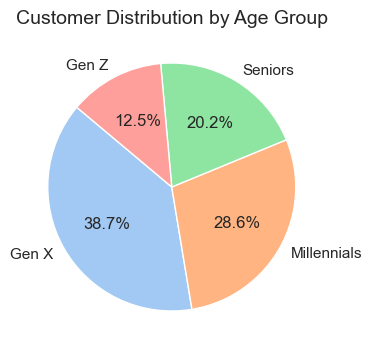

In [48]:
# 1. Age Group Distribution
plt.figure(figsize=(4, 8))
Customer_df['age_group'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Customer Distribution by Age Group', fontsize=14)
plt.ylabel('')
plt.show()

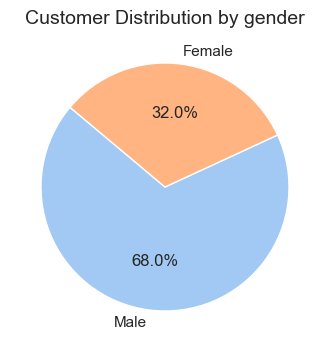

In [ ]:
# 1. Gender Distribution
plt.figure(figsize=(4, 8))
Customer_df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Customer Distribution by gender', fontsize=14)
plt.ylabel('')
plt.show()

C:\Users\peeyu\AppData\Local\Temp\ipykernel_34556\2628550751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')


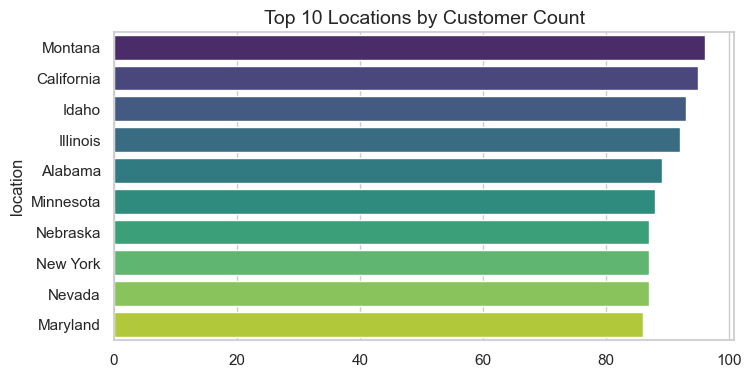

In [50]:
# 2. Top 10 Locations
plt.figure(figsize=(8, 4))
top_locations = Customer_df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Top 10 Locations by Customer Count', fontsize=14)
plt.show()


### 6.2 Revenue & Product Performance

In [1]:
# 1. Total Revenue by Category
plt.figure(figsize=(10, 6))
cat_revenue = Customer_df.groupby('category')['purchase_amount_usd'].sum().sort_values(ascending=False)
sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='magma')
plt.title('Total Revenue by Product Category', fontsize=16)
plt.ylabel('Total Sales (USD)')
plt.show()

NameError: name 'plt' is not defined

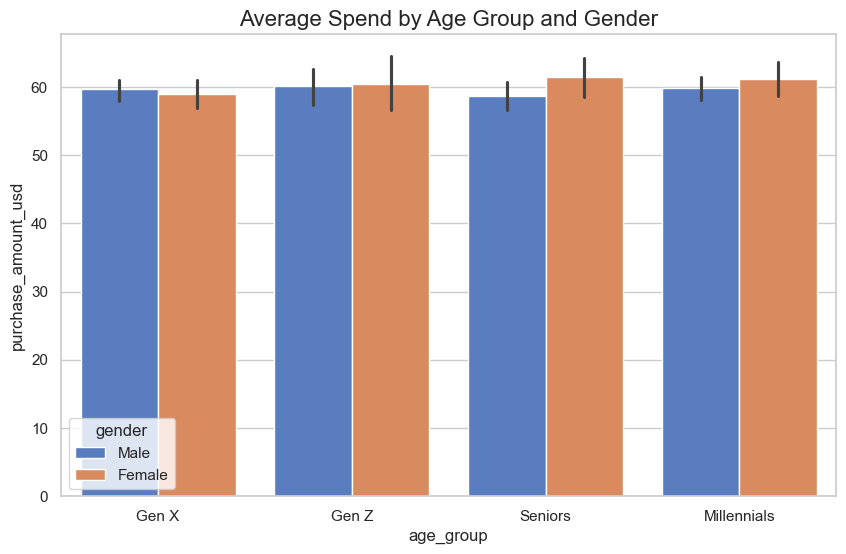

In [ ]:
# 2. Avg Spend by Age Group & Gender
plt.figure(figsize=(10, 6))
sns.barplot(data=Customer_df, x='age_group', y='purchase_amount_usd', hue='gender', palette='muted')
plt.title('Average Spend by Age Group and Gender', fontsize=16)
plt.show()

C:\Users\peeyu\AppData\Local\Temp\ipykernel_34556\3689479232.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='magma')


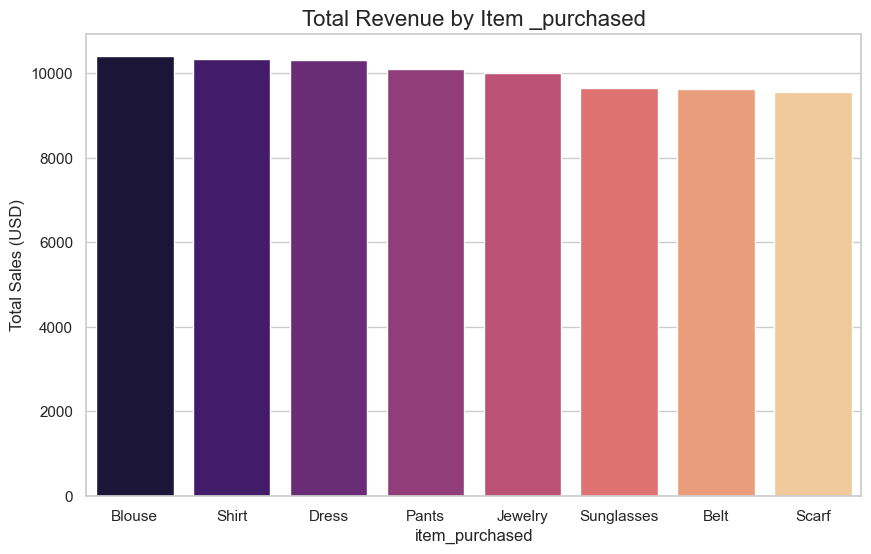

In [ ]:
# Top 8 Items (Count):
plt.figure(figsize=(10, 6))
cat_revenue = Customer_df.groupby('item_purchased')['purchase_amount_usd'].sum().sort_values(ascending=False).head(8)
sns.barplot(x=cat_revenue.index, y=cat_revenue.values, palette='magma')
plt.title('Total Revenue by Item _purchased', fontsize=16)
plt.ylabel('Total Sales (USD)')
plt.show()

C:\Users\peeyu\AppData\Local\Temp\ipykernel_34556\1641006125.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Customer_df, x='season', y='purchase_amount_usd', palette='Set2')


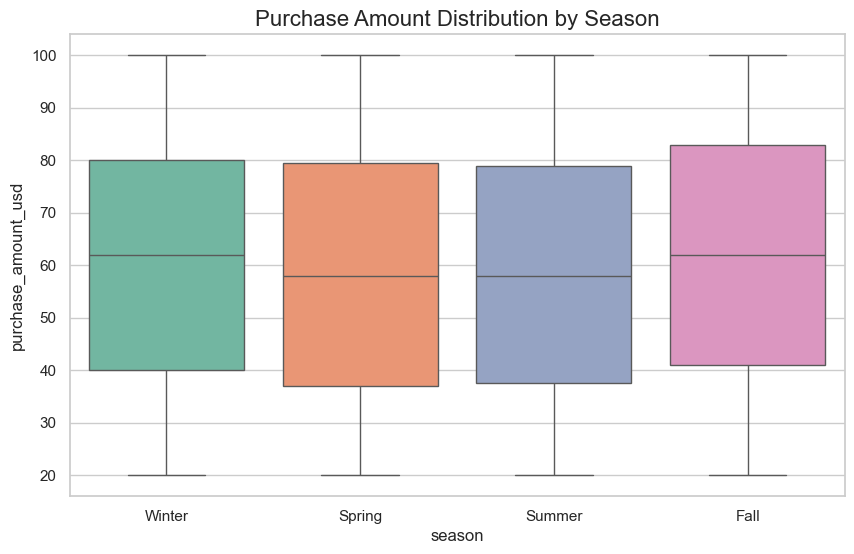

In [ ]:
# 1. Seasonality of Sales
plt.figure(figsize=(10, 6))
sns.boxplot(data=Customer_df, x='season', y='purchase_amount_usd', palette='Set2')
plt.title('Purchase Amount Distribution by Season', fontsize=16)
plt.show()

C:\Users\peeyu\AppData\Local\Temp\ipykernel_34556\3686008268.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Customer_df, x='subscription_status', y='previous_purchases', palette='coolwarm')


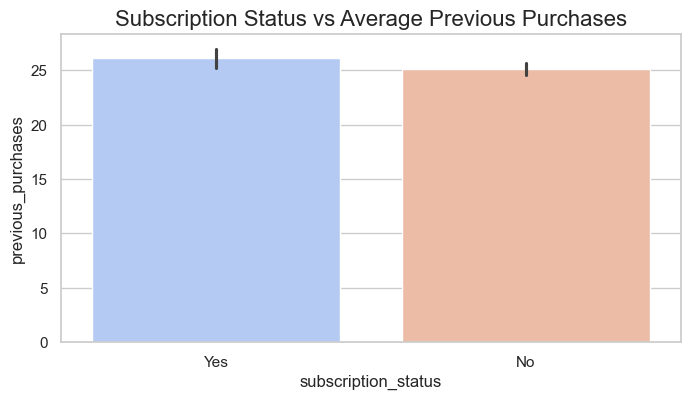

In [ ]:
# 2. Subscription Status vs Average Previous Purchases
plt.figure(figsize=(8,4))
sns.barplot(data=Customer_df, x='subscription_status', y='previous_purchases', palette='coolwarm')
plt.title('Subscription Status vs Average Previous Purchases', fontsize=16)
plt.show()

C:\Users\peeyu\AppData\Local\Temp\ipykernel_34556\2578572938.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


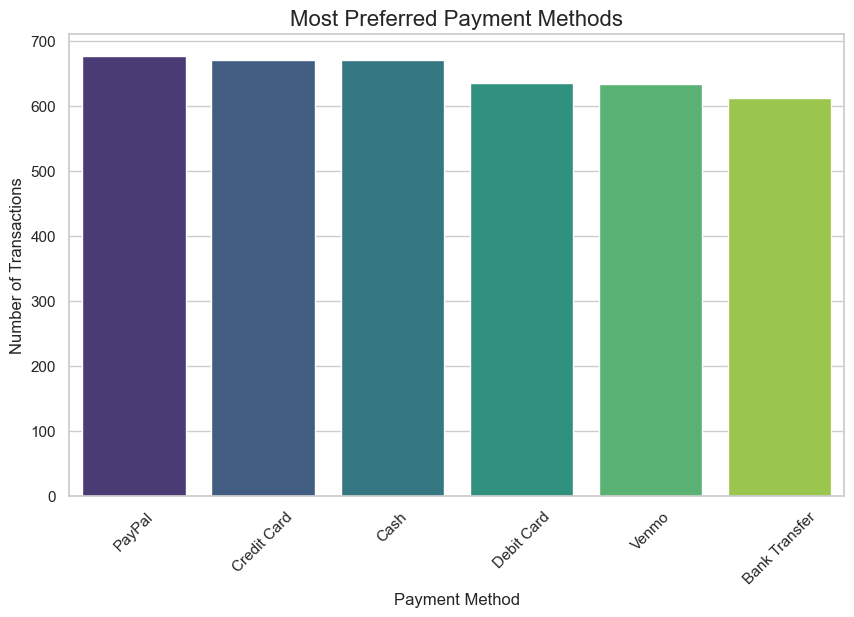

In [ ]:
# Payment Method Preferences (Count Plot)
plt.figure(figsize=(10, 6))

# Order the bars from most used to least used for better readability
payment_order = Customer_df['payment_method'].value_counts().index

sns.countplot(
    data=Customer_df, 
    x='payment_method', 
    order=payment_order, 
    palette='viridis'
)

plt.title('Most Preferred Payment Methods', fontsize=16)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=45) # Rotates labels to prevent overlapping
plt.show()

# 7. Database Integration

In [57]:
!pip install psycopg2-binary sqlalchemy


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"      # default user
password = "root" # the password you set during installation
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "customer_database"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer"   # choose any table name
Customer_df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'customer' in database 'customer_database'.
